# Wine Quality Regression Review

This notebook audits the combined white/red wine dataset, cleans duplicates, engineers features, builds a preprocessing pipeline, compares 10 regression models, and tunes the strongest candidates. The target is the numeric `quality` score.

## 1. Dataset Audit and EDA

In [26]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
DATA_PATH = 'winequality-red.csv'
df = pd.read_csv(DATA_PATH, sep=';')
df['type'] = 'red'
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


Shape: (1599, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  type                  1599 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 162.5 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,NaN,NaN,NaN,8.319637,1.741096,4.6,7.1,7.9,9.2,15.9
volatile acidity,1599.0,NaN,NaN,NaN,0.527821,0.17906,0.12,0.39,0.52,0.64,1.58
citric acid,1599.0,NaN,NaN,NaN,0.270976,0.194801,0.0,0.09,0.26,0.42,1.0
residual sugar,1599.0,NaN,NaN,NaN,2.538806,1.409928,0.9,1.9,2.2,2.6,15.5
chlorides,1599.0,NaN,NaN,NaN,0.087467,0.047065,0.012,0.07,0.079,0.09,0.611
free sulfur dioxide,1599.0,NaN,NaN,NaN,15.874922,10.460157,1.0,7.0,14.0,21.0,72.0
total sulfur dioxide,1599.0,NaN,NaN,NaN,46.467792,32.895324,6.0,22.0,38.0,62.0,289.0
density,1599.0,NaN,NaN,NaN,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,NaN,NaN,NaN,3.311113,0.154386,2.74,3.21,3.31,3.4,4.01
sulphates,1599.0,NaN,NaN,NaN,0.658149,0.169507,0.33,0.55,0.62,0.73,2.0


Missing values: fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64
Exact duplicate rows: 240


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

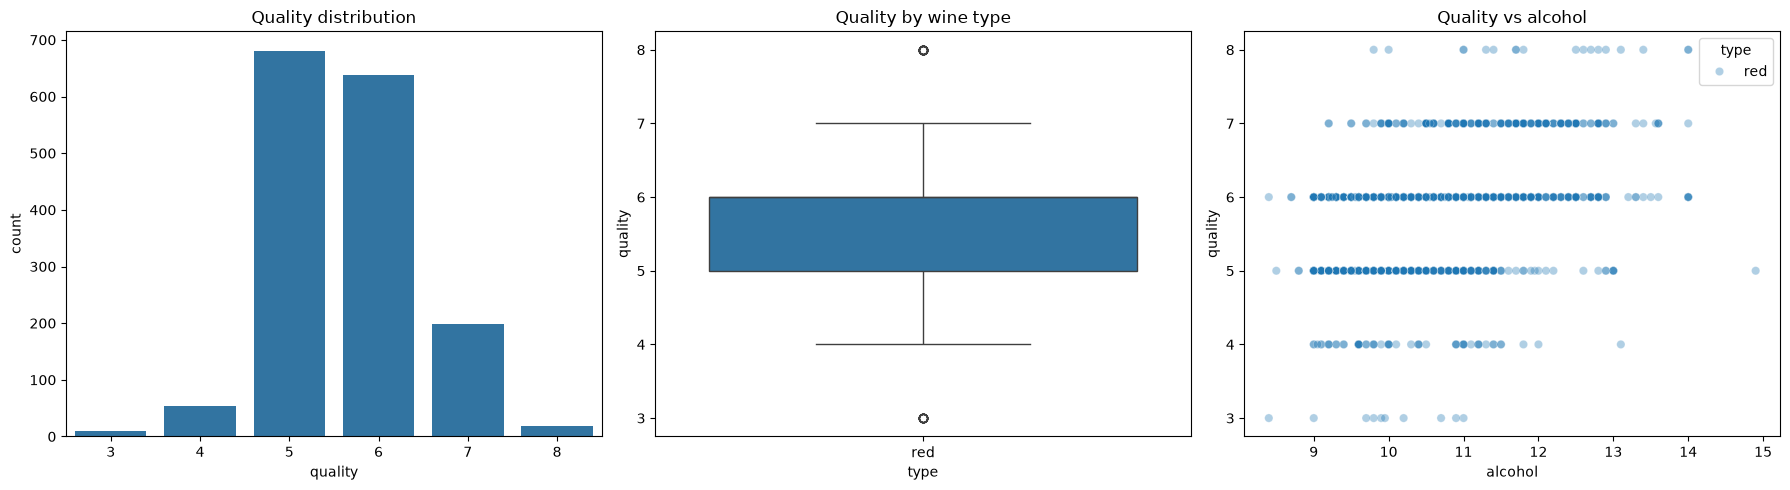

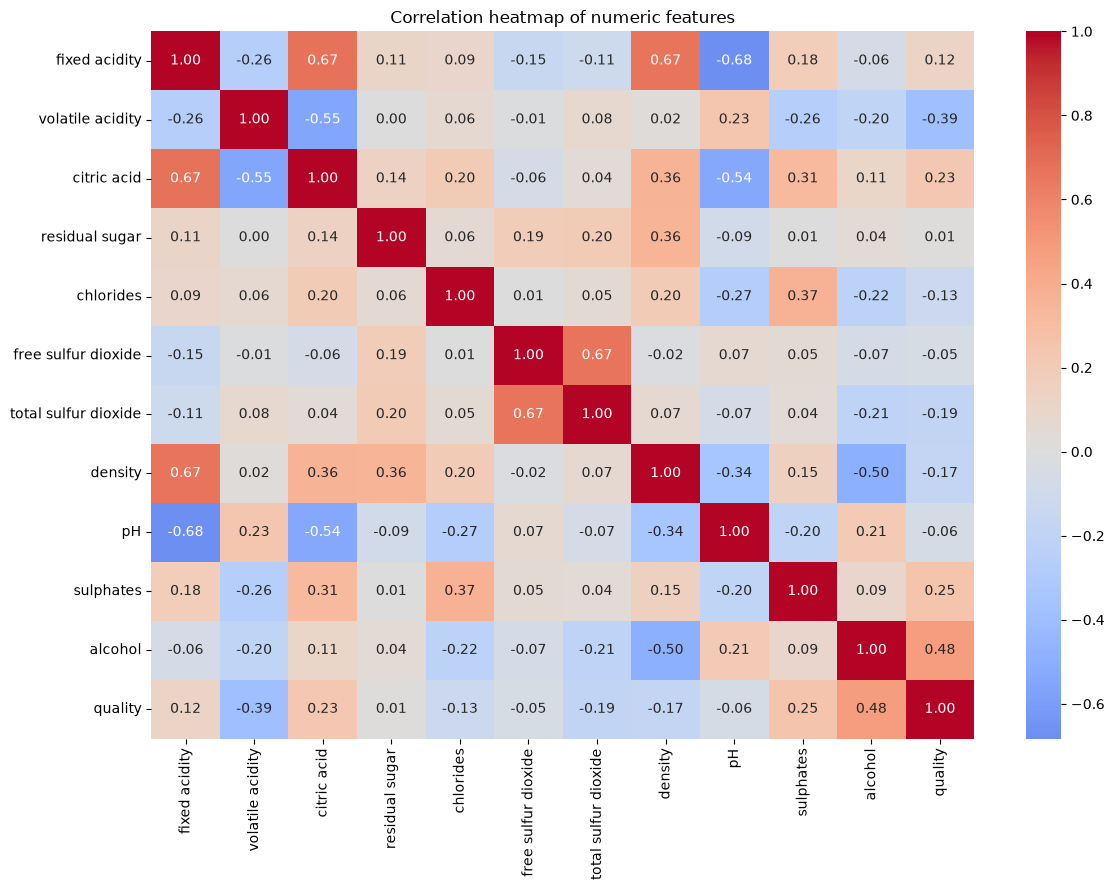

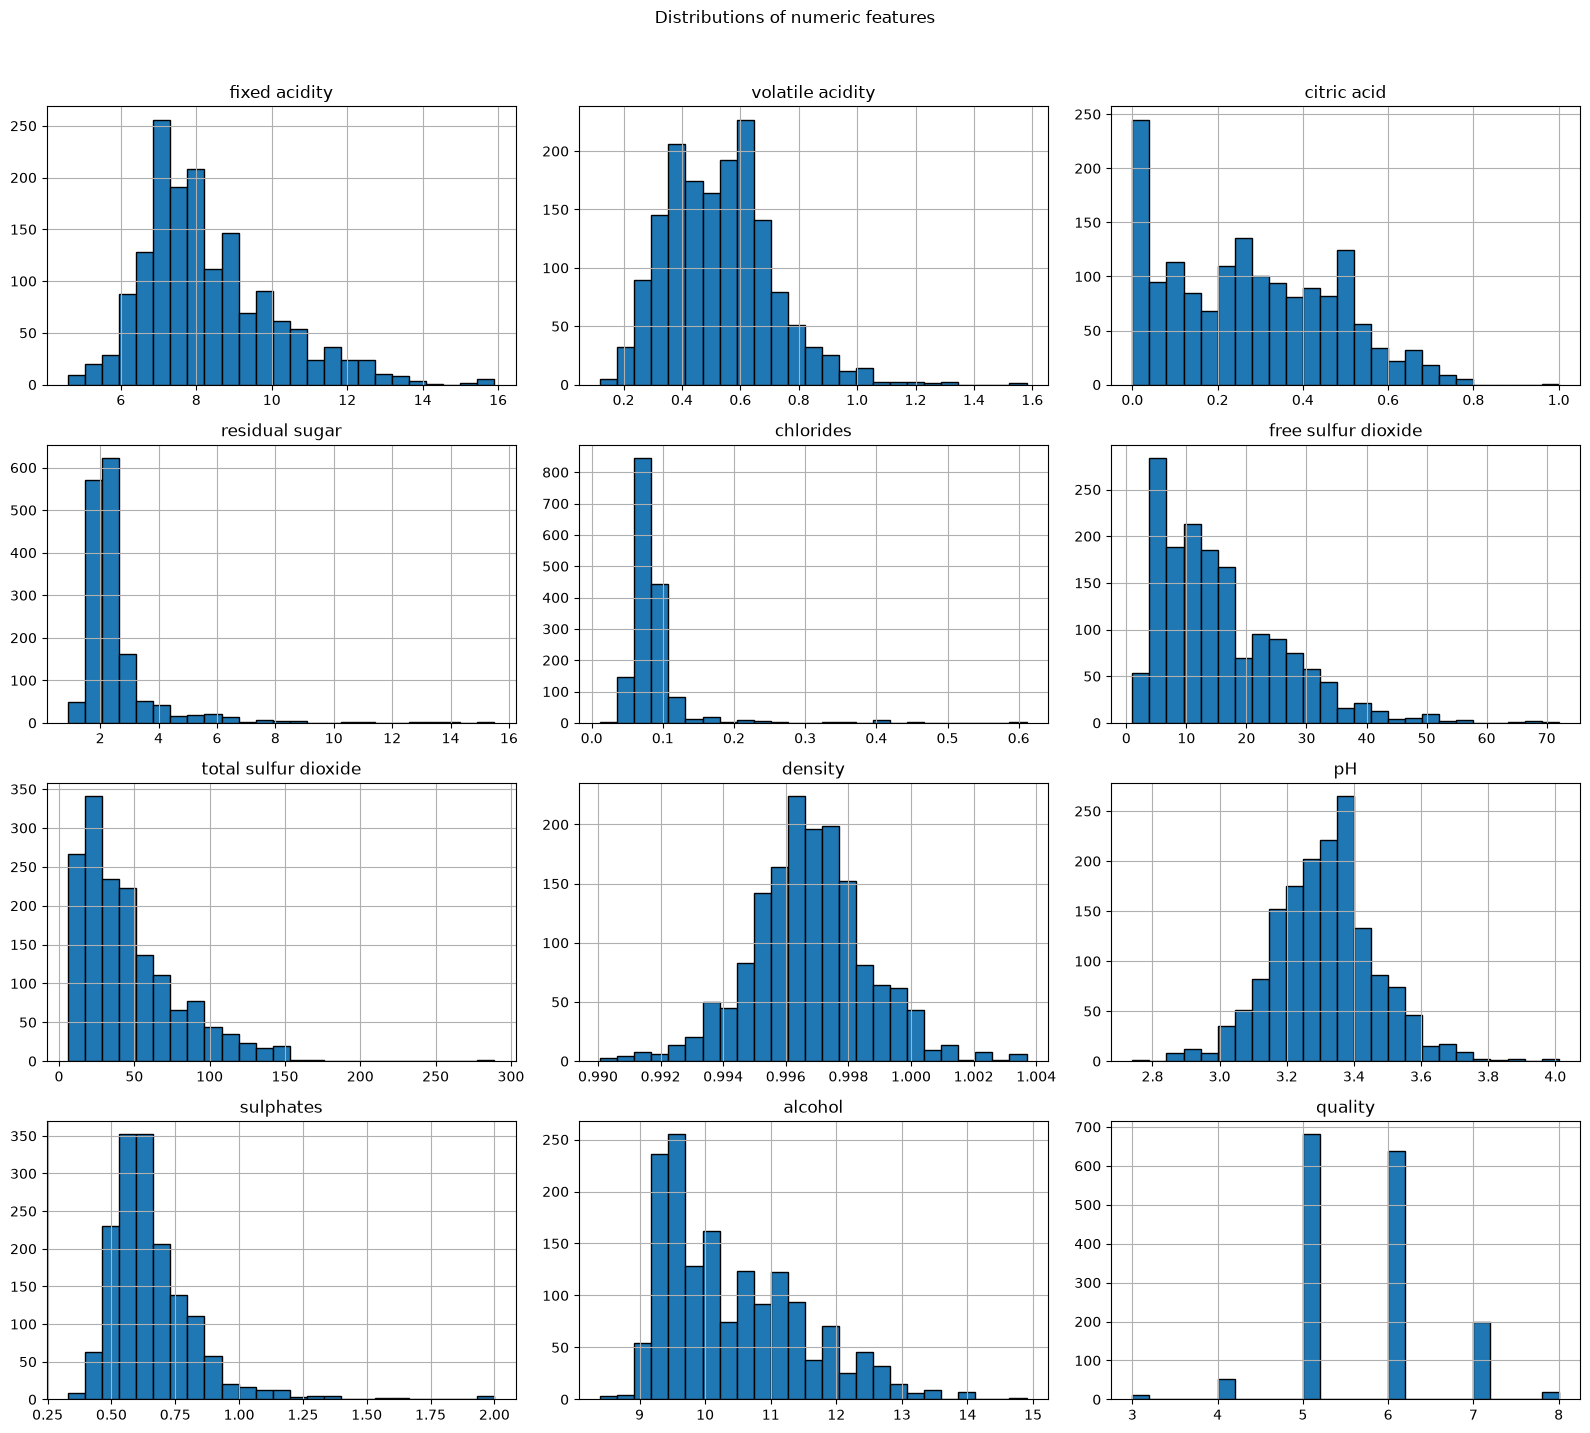

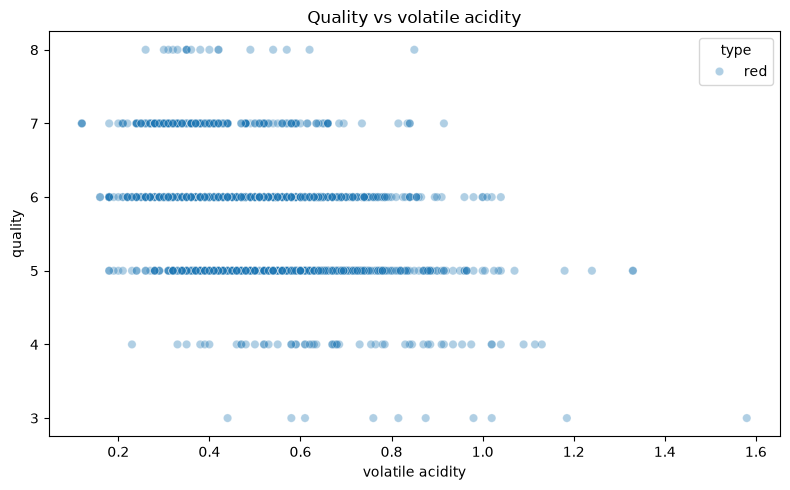

In [27]:
print('Shape:', df.shape)
display(df.info())
display(df.describe(include='all').T)
print('Missing values:', df.isna().sum())
print('Exact duplicate rows:', df.duplicated().sum())
display(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x='quality', ax=axes[0])
axes[0].set_title('Quality distribution')
sns.boxplot(data=df, x='type', y='quality', ax=axes[1])
axes[1].set_title('Quality by wine type')
sns.scatterplot(data=df, x='alcohol', y='quality', hue='type', alpha=0.35, ax=axes[2])
axes[2].set_title('Quality vs alcohol')
plt.tight_layout()
plt.show()

numeric_eda = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_eda.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap of numeric features')
plt.tight_layout()
plt.show()

numeric_eda.hist(figsize=(16, 14), bins=25, edgecolor='black')
plt.suptitle('Distributions of numeric features', y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='volatile acidity', y='quality', hue='type', alpha=0.35)
plt.title('Quality vs volatile acidity')
plt.tight_layout()
plt.show()

**EDA observation:** Quality is concentrated around the middle scores, and the alcohol relationship is positive but overlapping across wine types. The correlation heatmap highlights associations among chemical measurements, while the distribution plots show that several numeric variables are skewed. The additional volatile-acidity scatter plot suggests that higher volatile acidity is generally associated with lower quality, although the relationship is noisy.

## 2. Cleaning, Duplicates, and Outlier Review
Exact duplicates are removed. Numeric outliers are inspected with IQR counts and deliberately retained because they may represent legitimate wines and removing them before splitting could discard meaningful observations or introduce validation-set information into preprocessing.

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
outlier_report = []
for column in numeric_columns:
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    outlier_report.append({'feature': column, 'lower_bound': lower, 'upper_bound': upper, 'outlier_count': count})
display(pd.DataFrame(outlier_report).sort_values('outlier_count', ascending=False))
print('Cleaned shape:', df.shape)

,feature,lower_bound,upper_bound,outlier_count
3,residual sugar,0.85000,3.65000,126
4,chlorides,0.03850,0.12250,87
9,sulphates,0.28000,1.00000,55
6,total sulfur dioxide,-39.50000,124.50000,45
0,fixed acidity,3.95000,12.35000,41
7,density,0.99227,1.00115,35
8,pH,2.92500,3.68500,28
11,quality,3.50000,7.50000,27
5,free sulfur dioxide,-14.00000,42.00000,26
1,volatile acidity,0.01500,1.01500,19


Cleaned shape: (1359, 12)


## 3. Feature Engineering

In [ ]:
def add_features(frame):
    result = frame.copy()
    result['free_to_total_sulfur_ratio'] = result['free sulfur dioxide'] / (result['total sulfur dioxide'] + 1e-6)
    result['acidity_balance'] = result['fixed acidity'] + result['volatile acidity'] + result['citric acid']
    result['sugar_to_alcohol_ratio'] = result['residual sugar'] / (result['alcohol'] + 1e-6)
    result['alcohol_squared'] = result['alcohol'] ** 2
    return result

model_data = add_features(df)
X = model_data.drop(columns='quality')
y = model_data['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
print('Numeric features:', len(numeric_features))
print('Categorical features:', categorical_features)

Numeric features: 15
Categorical features: []


**Feature-engineering rationale:** The sulfur ratio captures the proportion of free sulfur dioxide relative to total sulfur dioxide, which may reflect preservation balance. Acidity balance combines fixed acidity, volatile acidity, and citric acid into a compact measure of perceived tartness and chemical balance. The sugar-to-alcohol ratio represents sweetness relative to alcohol strength, and alcohol squared lets linear models represent a possible nonlinear relationship between alcohol level and perceived quality.

## 4. Leakage-Aware Preprocessing Pipeline

In [ ]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])

def make_pipeline(model):
    return Pipeline([('preprocessor', preprocessor), ('model', model)])

## 5. Ten Regression Models

In [66]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_models = {}

def plot_model_diagnostics(model_name, predictions):
    actual = np.asarray(y_test)
    predicted = np.asarray(predictions)
    residuals = actual - predicted
    sample_count = min(50, len(actual))
    sample_index = np.arange(sample_count)

    plt.figure(figsize=(12, 5))
    if model_name == 'Linear Regression':
        plt.plot(sample_index, actual[:sample_count], label='Actual', marker='o', markersize=3)
        plt.plot(sample_index, predicted[:sample_count], label='Predicted', marker='o', markersize=3)
        plt.xlabel('Test sample')
        plt.ylabel('Quality')
        plt.legend()
        chart_type = 'line graph'
    elif model_name == 'Ridge':
        bar_index = np.arange(min(12, len(actual)))
        bar_width = 0.4
        plt.bar(bar_index - bar_width / 2, actual[:len(bar_index)], bar_width, label='Actual')
        plt.bar(bar_index + bar_width / 2, predicted[:len(bar_index)], bar_width, label='Predicted')
        plt.xlabel('Test sample')
        plt.ylabel('Quality')
        plt.legend()
        chart_type = 'bar graph'
    elif model_name == 'Lasso':
        plt.hist(residuals, bins=15, color='#a65628', edgecolor='black')
        plt.axvline(0, color='black', linestyle='--')
        plt.xlabel('Residual (actual - predicted)')
        plt.ylabel('Frequency')
        chart_type = 'histogram'
    elif model_name == 'ElasticNet':
        plt.scatter(actual, predicted, alpha=0.5)
        plot_limits = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
        plt.plot(plot_limits, plot_limits, color='black', linestyle='--')
        plt.xlabel('Actual quality')
        plt.ylabel('Predicted quality')
        chart_type = 'scatter plot'
    elif model_name == 'Polynomial Regression':
        pie_counts = [
            np.sum(residuals > 0.5),
            np.sum(np.abs(residuals) <= 0.5),
            np.sum(residuals < -0.5)
        ]
        plt.pie(
            pie_counts,
            labels=['Under-predicted', 'Close (±0.5)', 'Over-predicted'],
            autopct='%1.1f%%',
            startangle=90
        )
        chart_type = 'pie chart'
    elif model_name == 'KNN':
        plt.boxplot([actual, predicted], tick_labels=['Actual', 'Predicted'])
        plt.ylabel('Quality')
        chart_type = 'box plot'
    elif model_name == 'SVR':
        plt.fill_between(sample_index, actual[:sample_count], predicted[:sample_count], alpha=0.35, label='Prediction gap')
        plt.plot(sample_index, actual[:sample_count], label='Actual')
        plt.plot(sample_index, predicted[:sample_count], label='Predicted')
        plt.xlabel('Test sample')
        plt.ylabel('Quality')
        plt.legend()
        chart_type = 'area graph'
    elif model_name == 'Random Forest':
        plt.hexbin(actual, predicted, gridsize=15, cmap='viridis', mincnt=1)
        plot_limits = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
        plt.plot(plot_limits, plot_limits, color='red', linestyle='--')
        plt.xlabel('Actual quality')
        plt.ylabel('Predicted quality')
        plt.colorbar(label='Sample count')
        chart_type = 'hexbin plot'
    elif model_name == 'Gradient Boosting':
        plt.stem(sample_index, residuals[:sample_count])
        plt.axhline(0, color='black', linestyle='--')
        plt.xlabel('Test sample')
        plt.ylabel('Residual')
        chart_type = 'stem plot'
    else:
        plt.step(sample_index, actual[:sample_count], where='mid', label='Actual')
        plt.step(sample_index, predicted[:sample_count], where='mid', label='Predicted')
        plt.xlabel('Test sample')
        plt.ylabel('Quality')
        plt.legend()
        chart_type = 'step graph'

    plt.title(f'{model_name}: {chart_type}')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

{'model': 'Linear Regression', 'CV RMSE': np.float64(0.6696364548727737), 'Test RMSE': 0.6584574576709298, 'Test MAE': 0.5017480911211024, 'Test R2': 0.38792597393391426}


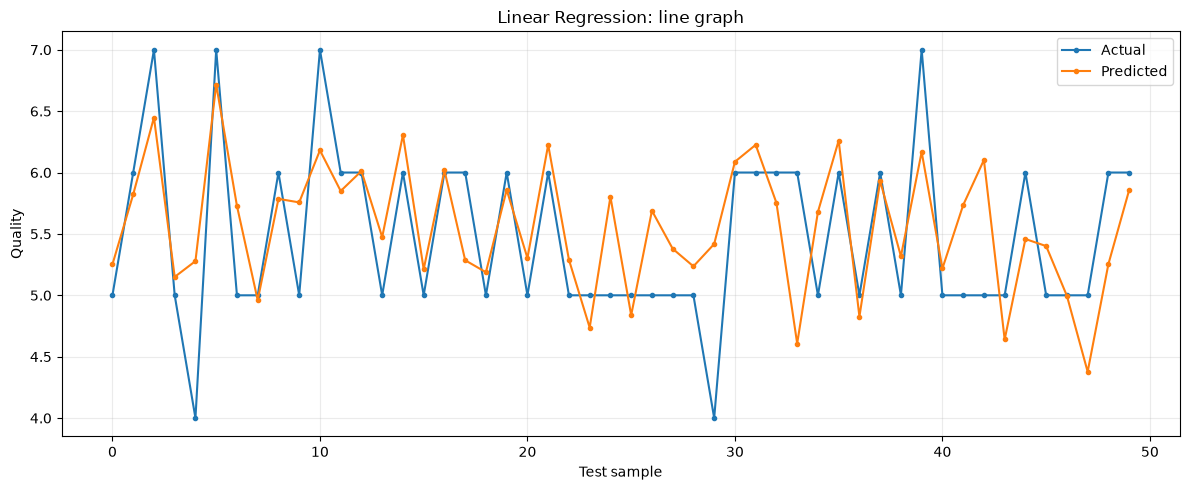

In [60]:
model = LinearRegression()
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['Linear Regression'] = pipeline
results.append({'model': 'Linear Regression', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('Linear Regression', predictions)

{'model': 'Ridge', 'CV RMSE': np.float64(0.6689675802233493), 'Test RMSE': 0.6559980435992975, 'Test MAE': 0.5013679609174213, 'Test R2': 0.39248976811646297}


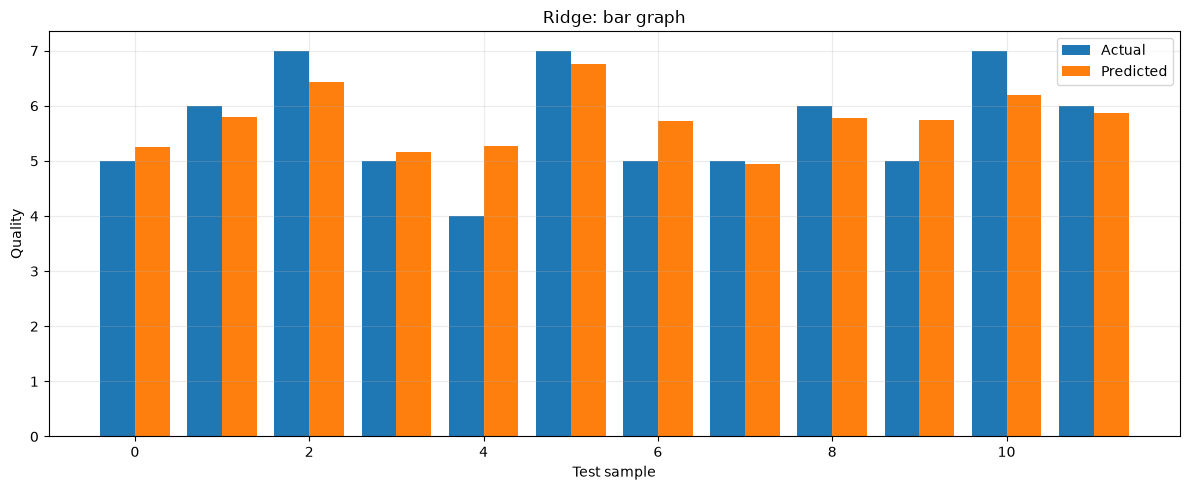

In [61]:
model = Ridge(alpha=1.0)
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['Ridge'] = pipeline
results.append({'model': 'Ridge', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('Ridge', predictions)

{'model': 'Lasso', 'CV RMSE': np.float64(0.6686392957109792), 'Test RMSE': 0.6529823406940708, 'Test MAE': 0.5011031955591317, 'Test R2': 0.39806252633963735}


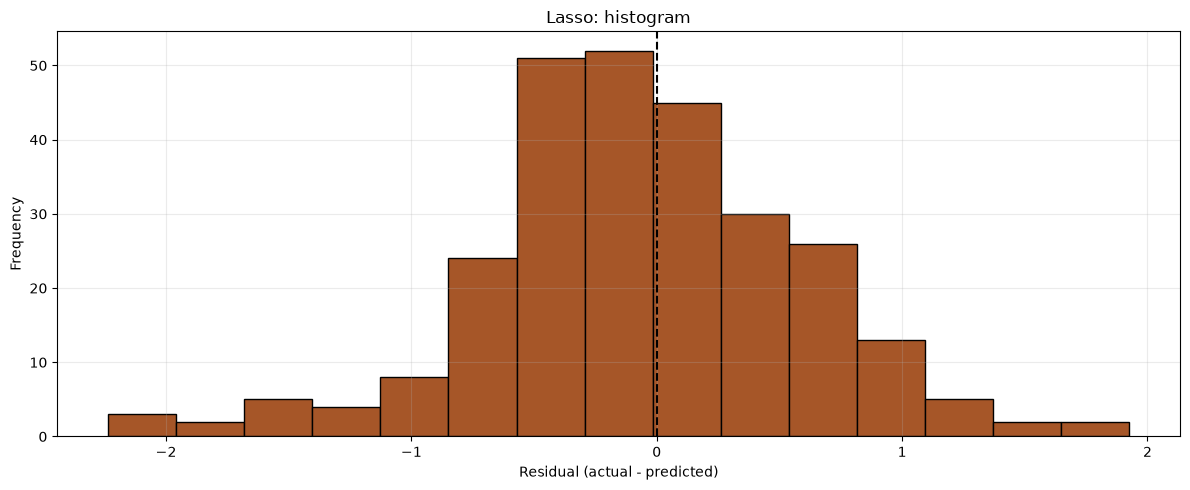

In [62]:
model = Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE)
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['Lasso'] = pipeline
results.append({'model': 'Lasso', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('Lasso', predictions)

{'model': 'ElasticNet', 'CV RMSE': np.float64(0.6663247162064897), 'Test RMSE': 0.6510470261264379, 'Test MAE': 0.5002858887955146, 'Test R2': 0.40162529354486665}


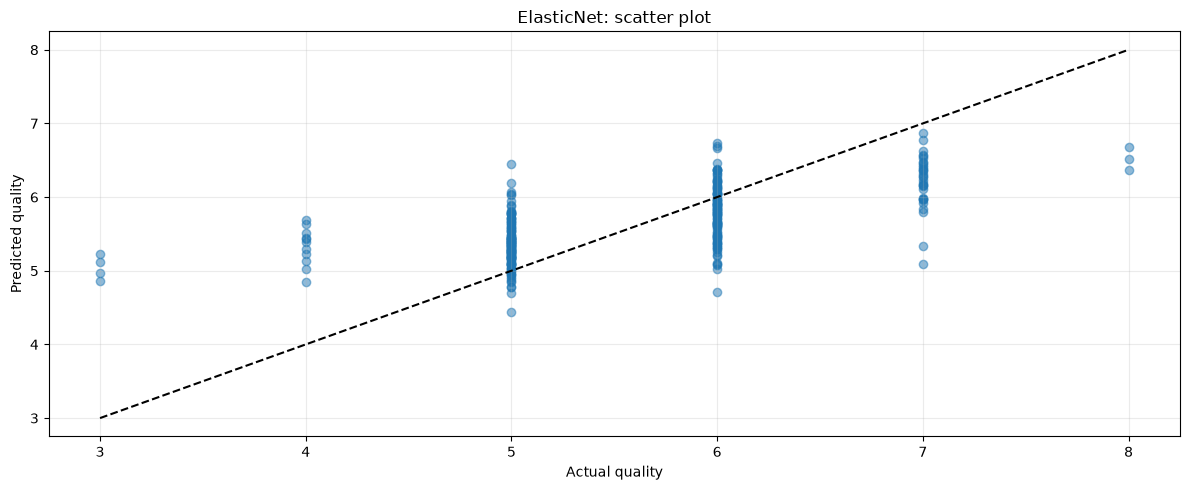

In [63]:
model = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE)
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['ElasticNet'] = pipeline
results.append({'model': 'ElasticNet', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('ElasticNet', predictions)

{'model': 'Polynomial Regression', 'CV RMSE': np.float64(0.7665816869953914), 'Test RMSE': 0.6732258898825015, 'Test MAE': 0.5166509824948387, 'Test R2': 0.3601618565798951}


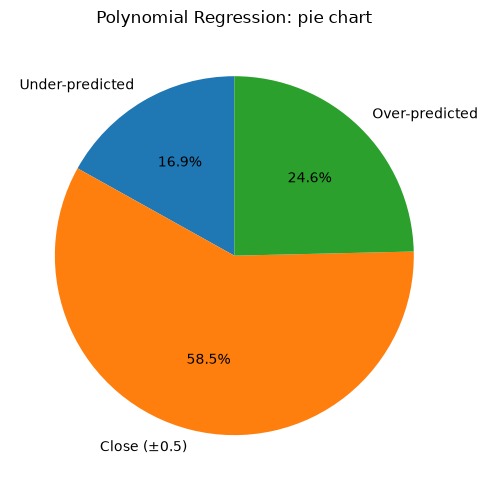

In [64]:
model = Pipeline([('polynomial', PolynomialFeatures(degree=2, include_bias=False)), ('linear', LinearRegression())])
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['Polynomial Regression'] = pipeline
results.append({'model': 'Polynomial Regression', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('Polynomial Regression', predictions)

{'model': 'KNN', 'CV RMSE': np.float64(0.6899107406797069), 'Test RMSE': 0.6692566112969718, 'Test MAE': 0.5136029411764705, 'Test R2': 0.36768446963191936}


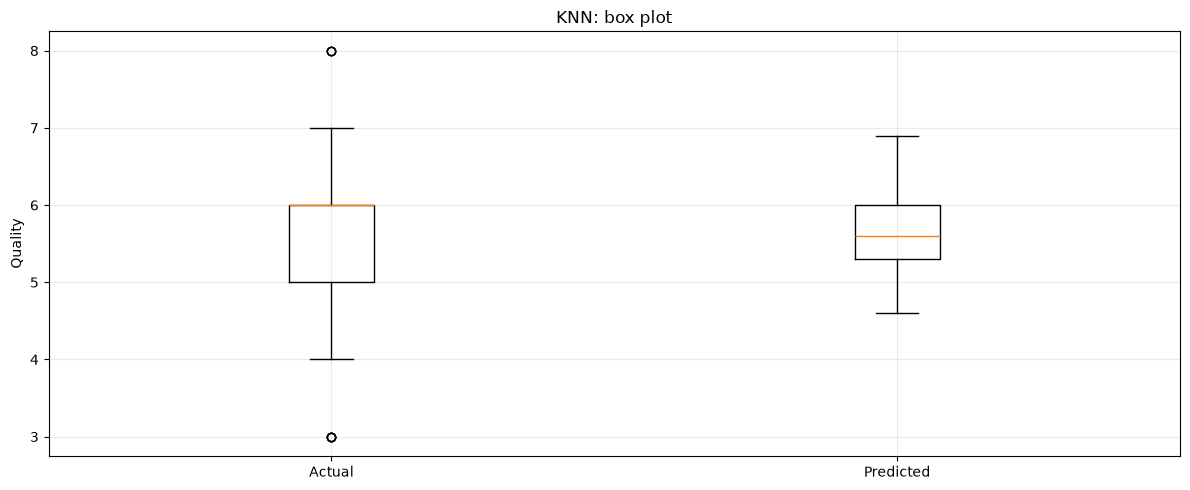

In [67]:
model = KNeighborsRegressor(n_neighbors=10)
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['KNN'] = pipeline
results.append({'model': 'KNN', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('KNN', predictions)

{'model': 'SVR', 'CV RMSE': np.float64(0.7278545122659122), 'Test RMSE': 0.6875080915807321, 'Test MAE': 0.5164868792902643, 'Test R2': 0.33272610252125245}


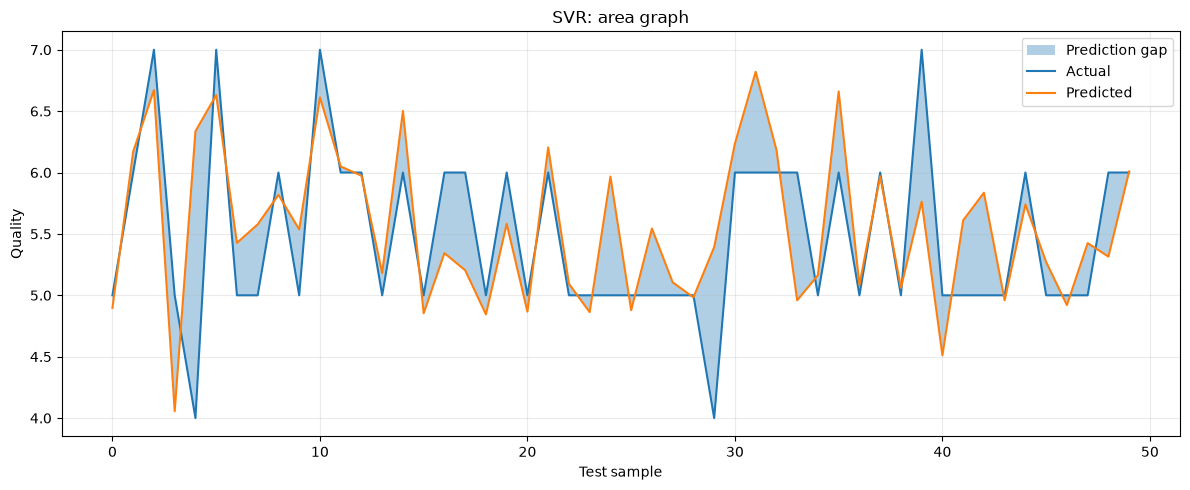

In [68]:
model = SVR(C=10, epsilon=0.1)
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['SVR'] = pipeline
results.append({'model': 'SVR', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('SVR', predictions)

{'model': 'Random Forest', 'CV RMSE': np.float64(0.6558020328877463), 'Test RMSE': 0.6214066585530909, 'Test MAE': 0.4679117647058823, 'Test R2': 0.4548697106875036}


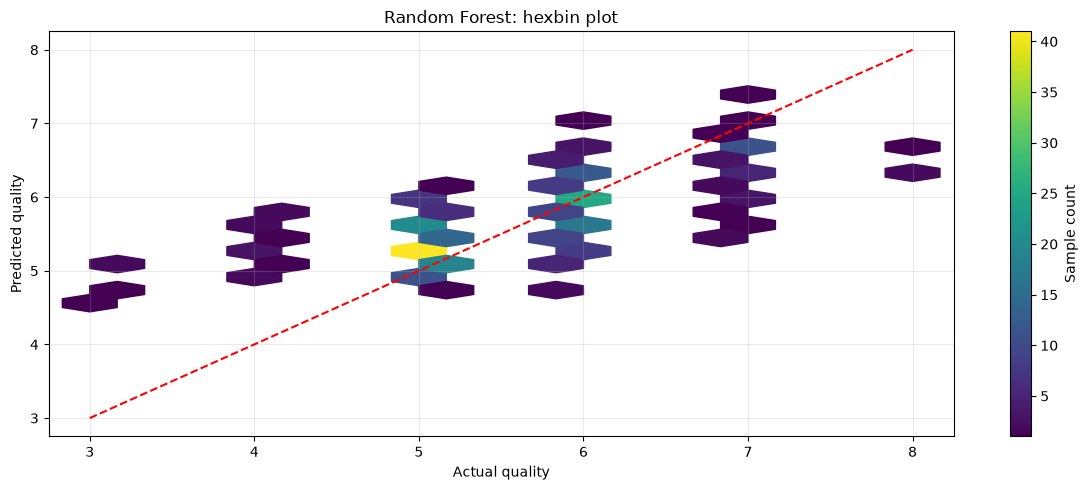

In [69]:
model = RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1)
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['Random Forest'] = pipeline
results.append({'model': 'Random Forest', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('Random Forest', predictions)

{'model': 'Gradient Boosting', 'CV RMSE': np.float64(0.6687201549692434), 'Test RMSE': 0.6155318826141465, 'Test MAE': 0.47490685637198016, 'Test R2': 0.4651283069418606}


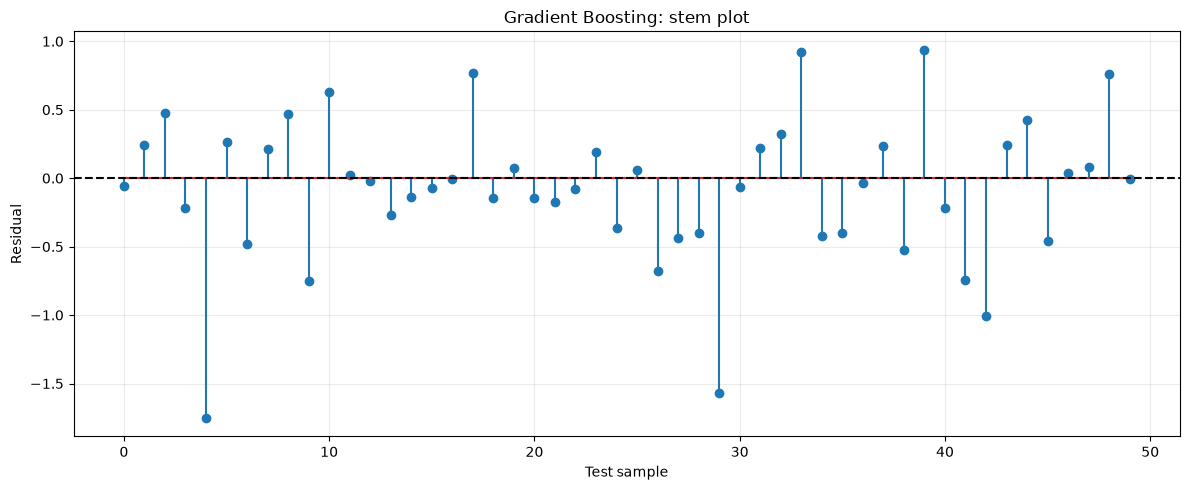

In [70]:
model = GradientBoostingRegressor(random_state=RANDOM_STATE)
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['Gradient Boosting'] = pipeline
results.append({'model': 'Gradient Boosting', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('Gradient Boosting', predictions)

{'model': 'Decision Tree', 'CV RMSE': np.float64(0.938241802238451), 'Test RMSE': 0.9235481451827989, 'Test MAE': 0.6102941176470589, 'Test R2': -0.2041139542427537}


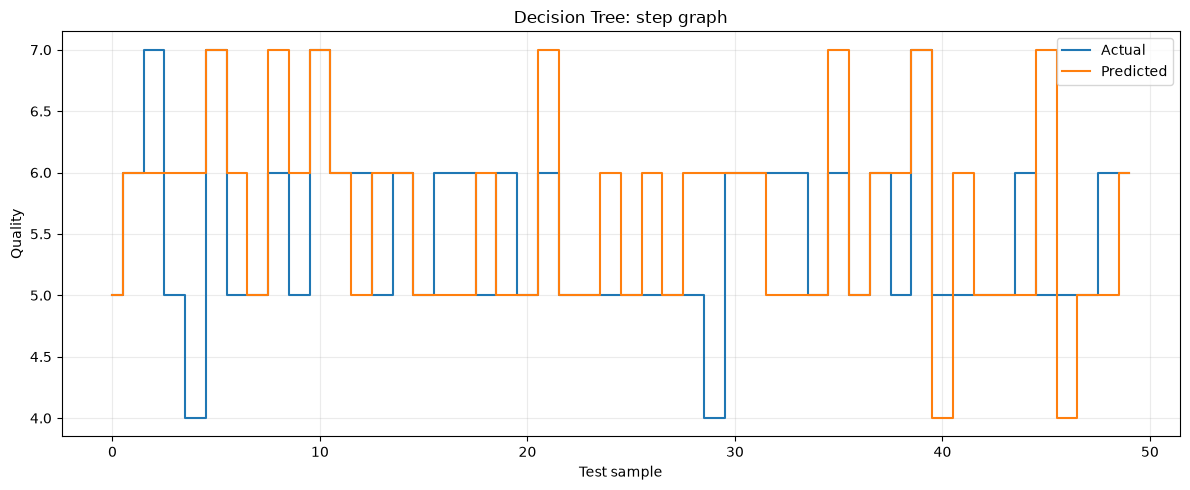

In [71]:
model = DecisionTreeRegressor(random_state=RANDOM_STATE)
pipeline = make_pipeline(model)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
fitted_models['Decision Tree'] = pipeline
results.append({'model': 'Decision Tree', 'CV RMSE': -scores.mean(), 'Test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'Test MAE': mean_absolute_error(y_test, predictions), 'Test R2': r2_score(y_test, predictions)})
print(results[-1])
plot_model_diagnostics('Decision Tree', predictions)

In [ ]:
comparison = pd.DataFrame(results).sort_values('Test R2', ascending=False)
display(comparison)

,model,CV RMSE,Test RMSE,Test MAE,Test R2
8,Gradient Boosting,0.668720,0.615532,0.474907,0.465128
7,Random Forest,0.655802,0.621407,0.467912,0.454870
3,ElasticNet,0.666325,0.651047,0.500286,0.401625
2,Lasso,0.668639,0.652982,0.501103,0.398063
1,Ridge,0.668968,0.655998,0.501368,0.392490
0,Linear Regression,0.669636,0.658457,0.501748,0.387926
5,KNN,0.689911,0.669257,0.513603,0.367684
4,Polynomial Regression,0.766582,0.673226,0.516651,0.360162
6,SVR,0.727855,0.687508,0.516487,0.332726
9,Decision Tree,0.938242,0.923548,0.610294,-0.204114


In [ ]:
polynomial_results = []
for degree in [2, 3]:
    polynomial_model = Pipeline([('polynomial', PolynomialFeatures(degree=degree, include_bias=False)), ('linear', LinearRegression())])
    polynomial_pipeline = make_pipeline(polynomial_model)
    degree_scores = cross_val_score(polynomial_pipeline, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    polynomial_pipeline.fit(X_train, y_train)
    degree_predictions = polynomial_pipeline.predict(X_test)
    polynomial_results.append({'degree': degree, 'CV RMSE': -degree_scores.mean(), 'Test RMSE': mean_squared_error(y_test, degree_predictions) ** 0.5, 'Test R2': r2_score(y_test, degree_predictions)})
display(pd.DataFrame(polynomial_results).sort_values('Test R2', ascending=False))

,degree,CV RMSE,Test RMSE,Test R2
0,2,0.766582,0.673226,0.360162
1,3,16.048306,6.630560,-61.065303


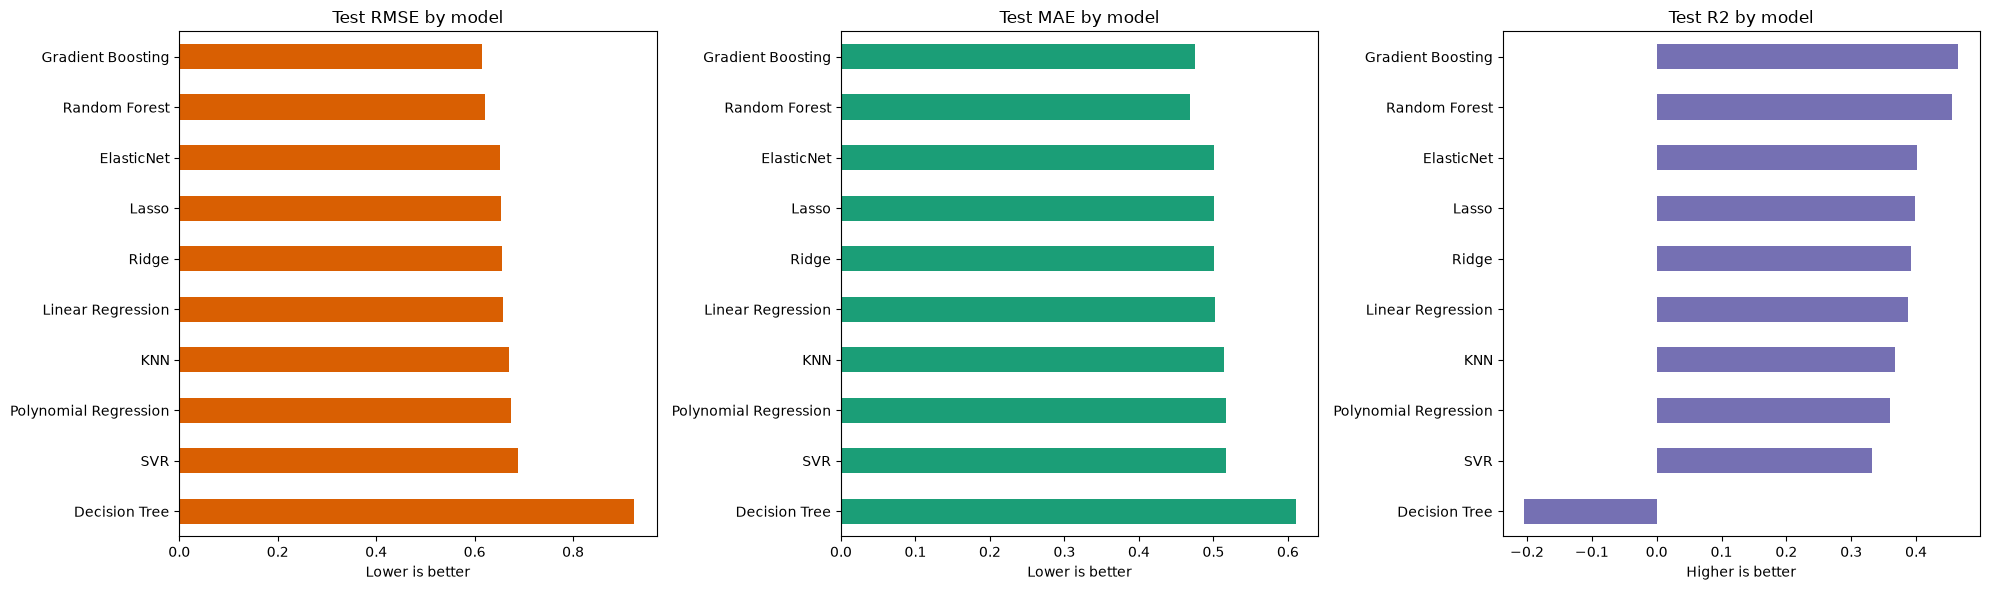

Run these model cells to add their diagnostics: Gradient Boosting, Random Forest


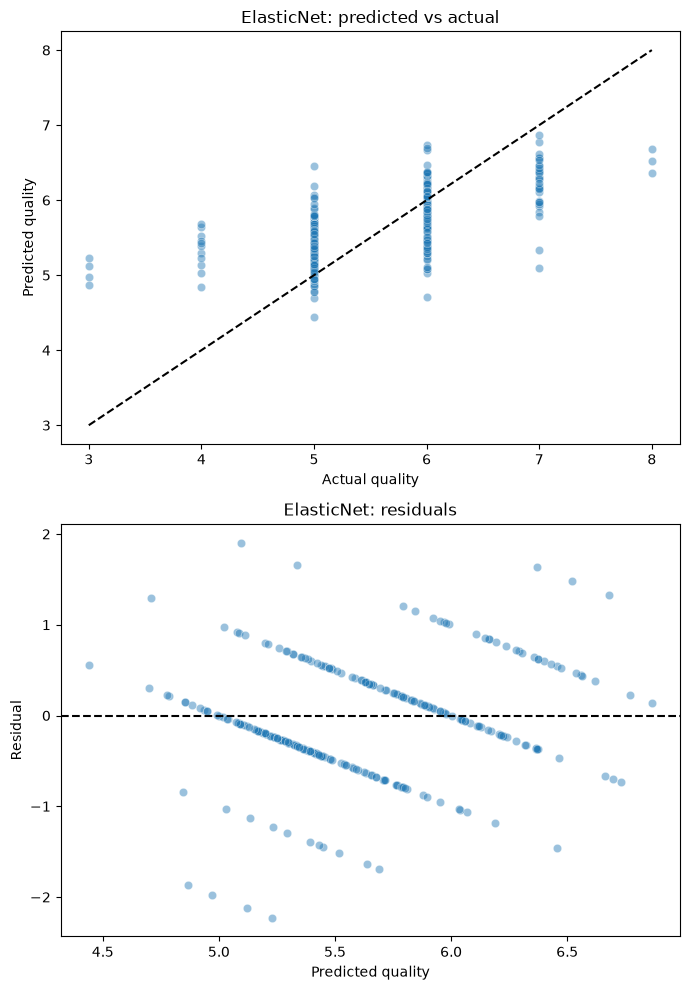

In [46]:
# Model performance comparison
plot_data = comparison.sort_values('Test R2', ascending=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_data.plot.barh(x='model', y='Test RMSE', ax=axes[0], color='#d95f02', legend=False)
axes[0].set_title('Test RMSE by model')
axes[0].set_xlabel('Lower is better')
axes[0].set_ylabel('')

plot_data.plot.barh(x='model', y='Test MAE', ax=axes[1], color='#1b9e77', legend=False)
axes[1].set_title('Test MAE by model')
axes[1].set_xlabel('Lower is better')
axes[1].set_ylabel('')

plot_data.plot.barh(x='model', y='Test R2', ax=axes[2], color='#7570b3', legend=False)
axes[2].set_title('Test R2 by model')
axes[2].set_xlabel('Higher is better')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# Prediction and residual graphs for the strongest currently fitted models
requested_models = comparison.head(3)['model'].tolist()
top_models = [name for name in requested_models if name in fitted_models]
missing_models = [name for name in requested_models if name not in fitted_models]
if missing_models:
    print('Run these model cells to add their diagnostics:', ', '.join(missing_models))

if top_models:
    fig, axes = plt.subplots(2, len(top_models), figsize=(7 * len(top_models), 10), squeeze=False)
    for index, name in enumerate(top_models):
        model_predictions = fitted_models[name].predict(X_test)
        model_residuals = y_test - model_predictions
        plot_limits = [min(y_test.min(), model_predictions.min()), max(y_test.max(), model_predictions.max())]

        sns.scatterplot(x=y_test, y=model_predictions, alpha=0.45, ax=axes[0, index])
        axes[0, index].plot(plot_limits, plot_limits, color='black', linestyle='--')
        axes[0, index].set_title(f'{name}: predicted vs actual')
        axes[0, index].set_xlabel('Actual quality')
        axes[0, index].set_ylabel('Predicted quality')

        sns.scatterplot(x=model_predictions, y=model_residuals, alpha=0.45, ax=axes[1, index])
        axes[1, index].axhline(0, color='black', linestyle='--')
        axes[1, index].set_title(f'{name}: residuals')
        axes[1, index].set_xlabel('Predicted quality')
        axes[1, index].set_ylabel('Residual')

    plt.tight_layout()
    plt.show()

# Feature importance for currently fitted tree-based models
tree_models = [name for name in ['Random Forest', 'Gradient Boosting', 'Decision Tree'] if name in fitted_models]
if tree_models:
    fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 6), squeeze=False)
    for index, name in enumerate(tree_models):
        axis = axes[0, index]
        tree_pipeline = fitted_models[name]
        tree_model = tree_pipeline.named_steps['model']
        tree_features = tree_pipeline.named_steps['preprocessor'].get_feature_names_out()
        tree_importance = pd.Series(tree_model.feature_importances_, index=tree_features).nlargest(12).sort_values()
        tree_importance.plot.barh(ax=axis, color='#66a61e')
        axis.set_title(f'{name}: top features')
        axis.set_xlabel('Importance')
        axis.set_ylabel('')

    plt.tight_layout()
    plt.show()

## 6. Comparison, Tuning, and Cross-Validation

In [45]:
tuning_spaces = {
    'Random Forest': (RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), {'model__n_estimators': [200, 400], 'model__max_depth': [None, 12, 24], 'model__min_samples_leaf': [1, 2]}),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=RANDOM_STATE), {'model__n_estimators': [100, 200], 'model__learning_rate': [0.03, 0.08], 'model__max_depth': [2, 3]}),
    'Ridge': (Ridge(), {'model__alpha': [0.01, 0.1, 1, 10, 100]})
}
tuned_results = []
for name, (model, params) in tuning_spaces.items():
    search = GridSearchCV(make_pipeline(model), params, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    predictions = search.predict(X_test)
    tuned_results.append({'model': name, 'best CV RMSE': -search.best_score_, 'test RMSE': mean_squared_error(y_test, predictions) ** 0.5, 'test MAE': mean_absolute_error(y_test, predictions), 'test R2': r2_score(y_test, predictions), 'best params': search.best_params_})
display(pd.DataFrame(tuned_results).sort_values('test RMSE'))

,model,best CV RMSE,test RMSE,test MAE,test R2,best params
0,Random Forest,0.653332,0.617467,0.463709,0.461759,"{'model__max_depth': 12, 'model__min_samples_l..."
1,Gradient Boosting,0.660359,0.629595,0.482656,0.440408,"{'model__learning_rate': 0.03, 'model__max_dep..."
2,Ridge,0.667929,0.651821,0.501764,0.400202,{'model__alpha': 100}


## 7. Best-Model Diagnostics and Feature Importance

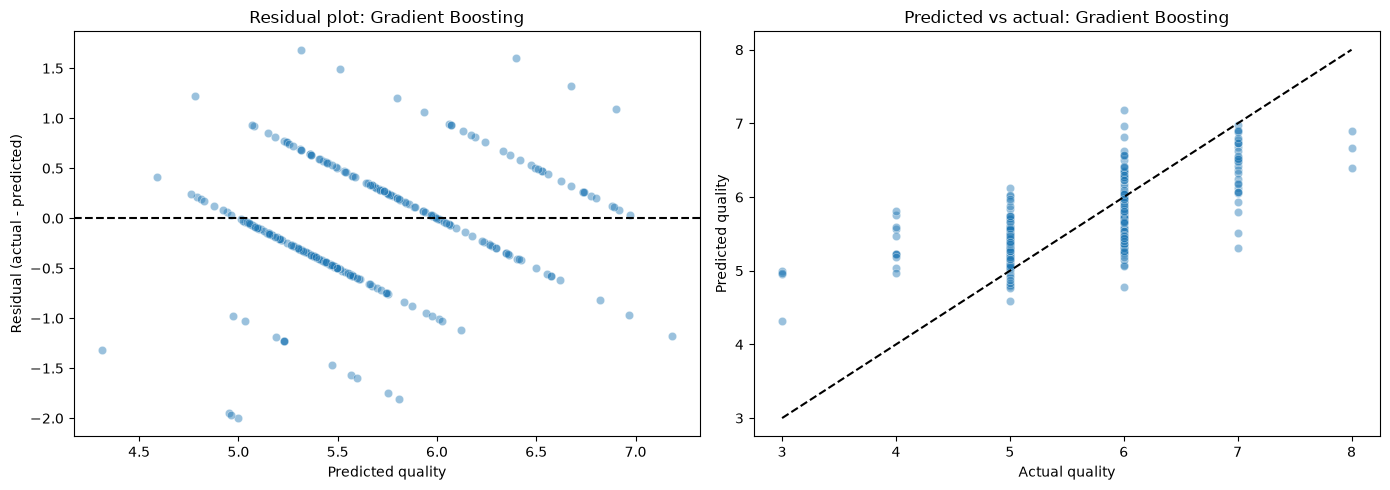

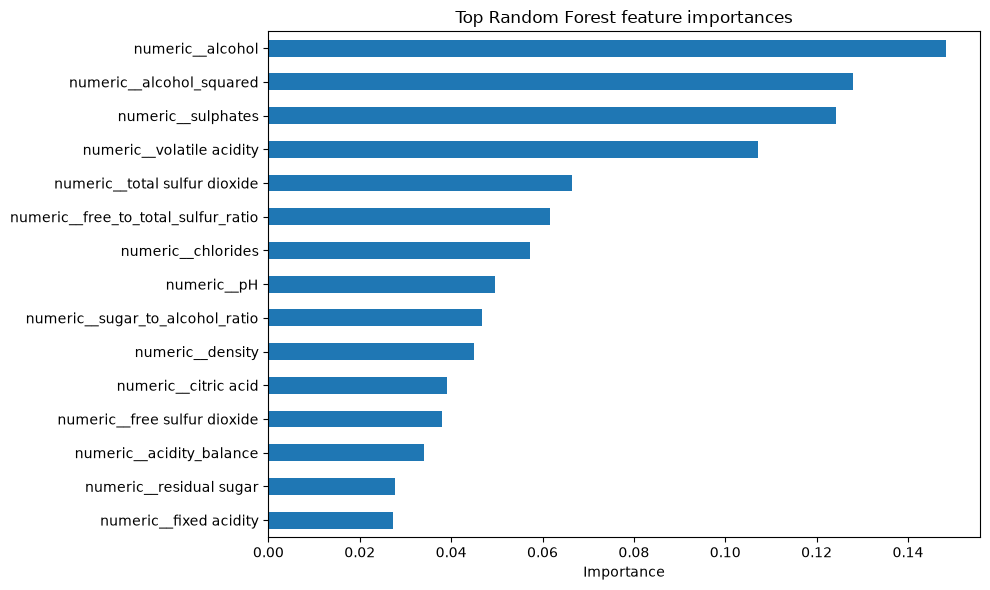

In [72]:
best_model_name = comparison.iloc[0]['model']
best_model = fitted_models[best_model_name]
best_predictions = best_model.predict(X_test)
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.45, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title(f'Residual plot: {best_model_name}')
axes[0].set_xlabel('Predicted quality')
axes[0].set_ylabel('Residual (actual - predicted)')

sns.scatterplot(x=y_test, y=best_predictions, alpha=0.45, ax=axes[1])
plot_limits = [min(y_test.min(), best_predictions.min()), max(y_test.max(), best_predictions.max())]
axes[1].plot(plot_limits, plot_limits, color='black', linestyle='--')
axes[1].set_title(f'Predicted vs actual: {best_model_name}')
axes[1].set_xlabel('Actual quality')
axes[1].set_ylabel('Predicted quality')
plt.tight_layout()
plt.show()

forest_pipeline = fitted_models['Random Forest']
feature_names = forest_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importances = forest_pipeline.named_steps['model'].feature_importances_
importance_table = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
importance_table.sort_values().plot(kind='barh')
plt.title('Top Random Forest feature importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Diagnostic observation:** A well-behaved residual plot should be centered around zero without a strong curve or funnel shape, while the predicted-vs-actual plot should cluster around the diagonal. The Random Forest importance chart identifies which transformed chemical measurements contribute most to its predictions; importance indicates predictive usefulness, not causation.

## 8. Review Notes
Use the sorted holdout R2 comparison together with cross-validated RMSE, MAE, and R2 to assess performance. The final choice should favor stable validation performance and interpretability, not only the single best holdout score.